# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import foxes
import foxes.variables as FV
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error,mean_squared_error
import customFunctions as fct
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn import neighbors, linear_model, gaussian_process
import os
import foxes.input.farm_layout as layout
import xarray as xr

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628','f781bf','999999'])
plt.rcParams['figure.figsize'] = [26.67/2, 13.25/2]
plt.rcParams['figure.dpi'] = 600

In [ ]:
data_ERA5 = fct.read_ts_csv(f'reanalysis.csv')
data_LIDAR = fct.read_ts_csv(f'measurements/lidar.csv')

# Resample the data to 1h intervals
data_ERA5 = data_ERA5.resample('h', on='Time').mean()
data_ERA5['u100'], data_ERA5['v100'] = fct.wind_components(data_ERA5.iloc[:, 0], data_ERA5.iloc[:, 1])

data_LIDAR = data_LIDAR.resample('h', on='Time').mean()
data_LIDAR['u99.2'], data_LIDAR['v99.2'] = fct.wind_components(data_LIDAR.iloc[:, 0], data_LIDAR.iloc[:, 1])

# create a merged dataframe containing the ERA5 and the LIDAR data
wind_data = pd.merge(data_LIDAR, data_ERA5, how='right', on='Time')

# Ensure that the datetime format is used for the datetime index
wind_data.index = pd.to_datetime(wind_data.index)

# Feature Engineering
wind_data['Mon']      = wind_data.index.strftime('%m')
wind_data['Hour']     = wind_data.index.strftime('%H')
wind_data["TI"] = 0.10  # constant turbulence

# Long-Term Wind Correction

In [2]:
import sklearn.gaussian_process


param_grid_KNeighbors = {
              "n_neighbors"       : [2, 5, 12, 30],
              "leaf_size"         : [1, 2, 3, 15,30],
              "p"                 : [1, 2],
              "weights"           : ['uniform', 'distance'],
              "metric"            : ['euclidean', 'manhattan', 'minkowski'] 
             }

param_grid_RadiusNeighborsRegressor = {
              "radius"            : np.arange(0.2, 2, .2),
              "leaf_size"         : np.arange(1, 10, 1),
              "p"                 : [1, 2],
              "weights"           : ['uniform', 'distance'],
              "metric"            : ['euclidean', 'manhattan', 'minkowski'] 
             }

param_grid_LinReg = {
            "fit_intercept"     : [False, True],
            "copy_X"            : [False, True]
}

# Define kernels:
ker_rbf = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.RBF(1.0, length_scale_bounds="fixed")

ker_rq = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.RationalQuadratic(alpha=0.1, length_scale=1)

ker_expsine = sklearn.gaussian_process.kernels.ConstantKernel(1.0, constant_value_bounds="fixed") * sklearn.gaussian_process.kernels.ExpSineSquared(1.0, 5.0, periodicity_bounds=(1e-2, 1e1))

kernel_list = [ker_rbf, ker_rq, ker_expsine]

param_grid_Gaussian = {
            "kernel"    : kernel_list, # ['ExpSineSquared', 'ConstantKernel', 'WhiteKernel']
            "alpha"     : np.arange(4, 10, 0.5) * 10 ** -10,
            "optimizer" : ['fmin_l_bfgs_b']
}

param_grids = [param_grid_LinReg, param_grid_KNeighbors, param_grid_Gaussian] # , param_grid_RadiusNeighborsRegressor

classifiers = [sklearn.linear_model.LinearRegression(), sklearn.neighbors.KNeighborsRegressor(), sklearn.gaussian_process.GaussianProcessRegressor()] # , sklearn.neighbors.RadiusNeighborsRegressor()
classifier_names = ['LinReg', 'KNeighbors', 'GaussianProcess'] # , 'GaussianProcess'
u_predictions = []
v_predictions = []


In [ ]:

for (grid, classifier, i) in zip(param_grids, classifiers, range(len(param_grids))) :
    u_pred, meas_idx, _ = fct.correct_long_term_wind(wind_data[['u100','WS100','WD100','Mon','Hour']], wind_data['u99.2'], 
                                                   classifier=classifier, param_grid=grid)

    v_pred, _, _ = fct.correct_long_term_wind(wind_data[['v100','WS100','WD100','Mon','Hour']], wind_data['v99.2'], 
                                                   classifier=classifier, param_grid=grid)
    u_predictions.append(u_pred)
    v_predictions.append(v_pred)
    del u_pred, v_pred
np.savetxt('meas_idx.txt', meas_idx)

In [ ]:
  
WS_predictions = []
WD_predictions = []

for (u, v)in zip(u_predictions, v_predictions):
    WS_pred, WD_pred = fct.wind_speed_dir(u, v)
    WS_predictions.append(WS_pred)
    WD_predictions.append(WD_pred)
    del WS_pred, WD_pred

# df_WS_predictions = pd.DataFrame(np.stack([pred.squeeze() for pred in WS_predictions]).transpose())
df_predictions = pd.DataFrame(np.concat([np.stack([pred.squeeze() for pred in WS_predictions]).transpose(), 
                                         np.stack([pred.squeeze() for pred in WD_predictions]).transpose()], axis=1))



wind_data['WS100_corr'], wind_data['WD100_corr'] = fct.wind_speed_dir(u_predictions[1], v_predictions[1])

# Store the corrected data, so it does not have to be rerun all the time
wind_data.to_pickle('wind_data')
df_predictions.to_pickle('WS_WD_predictions')

## Figures

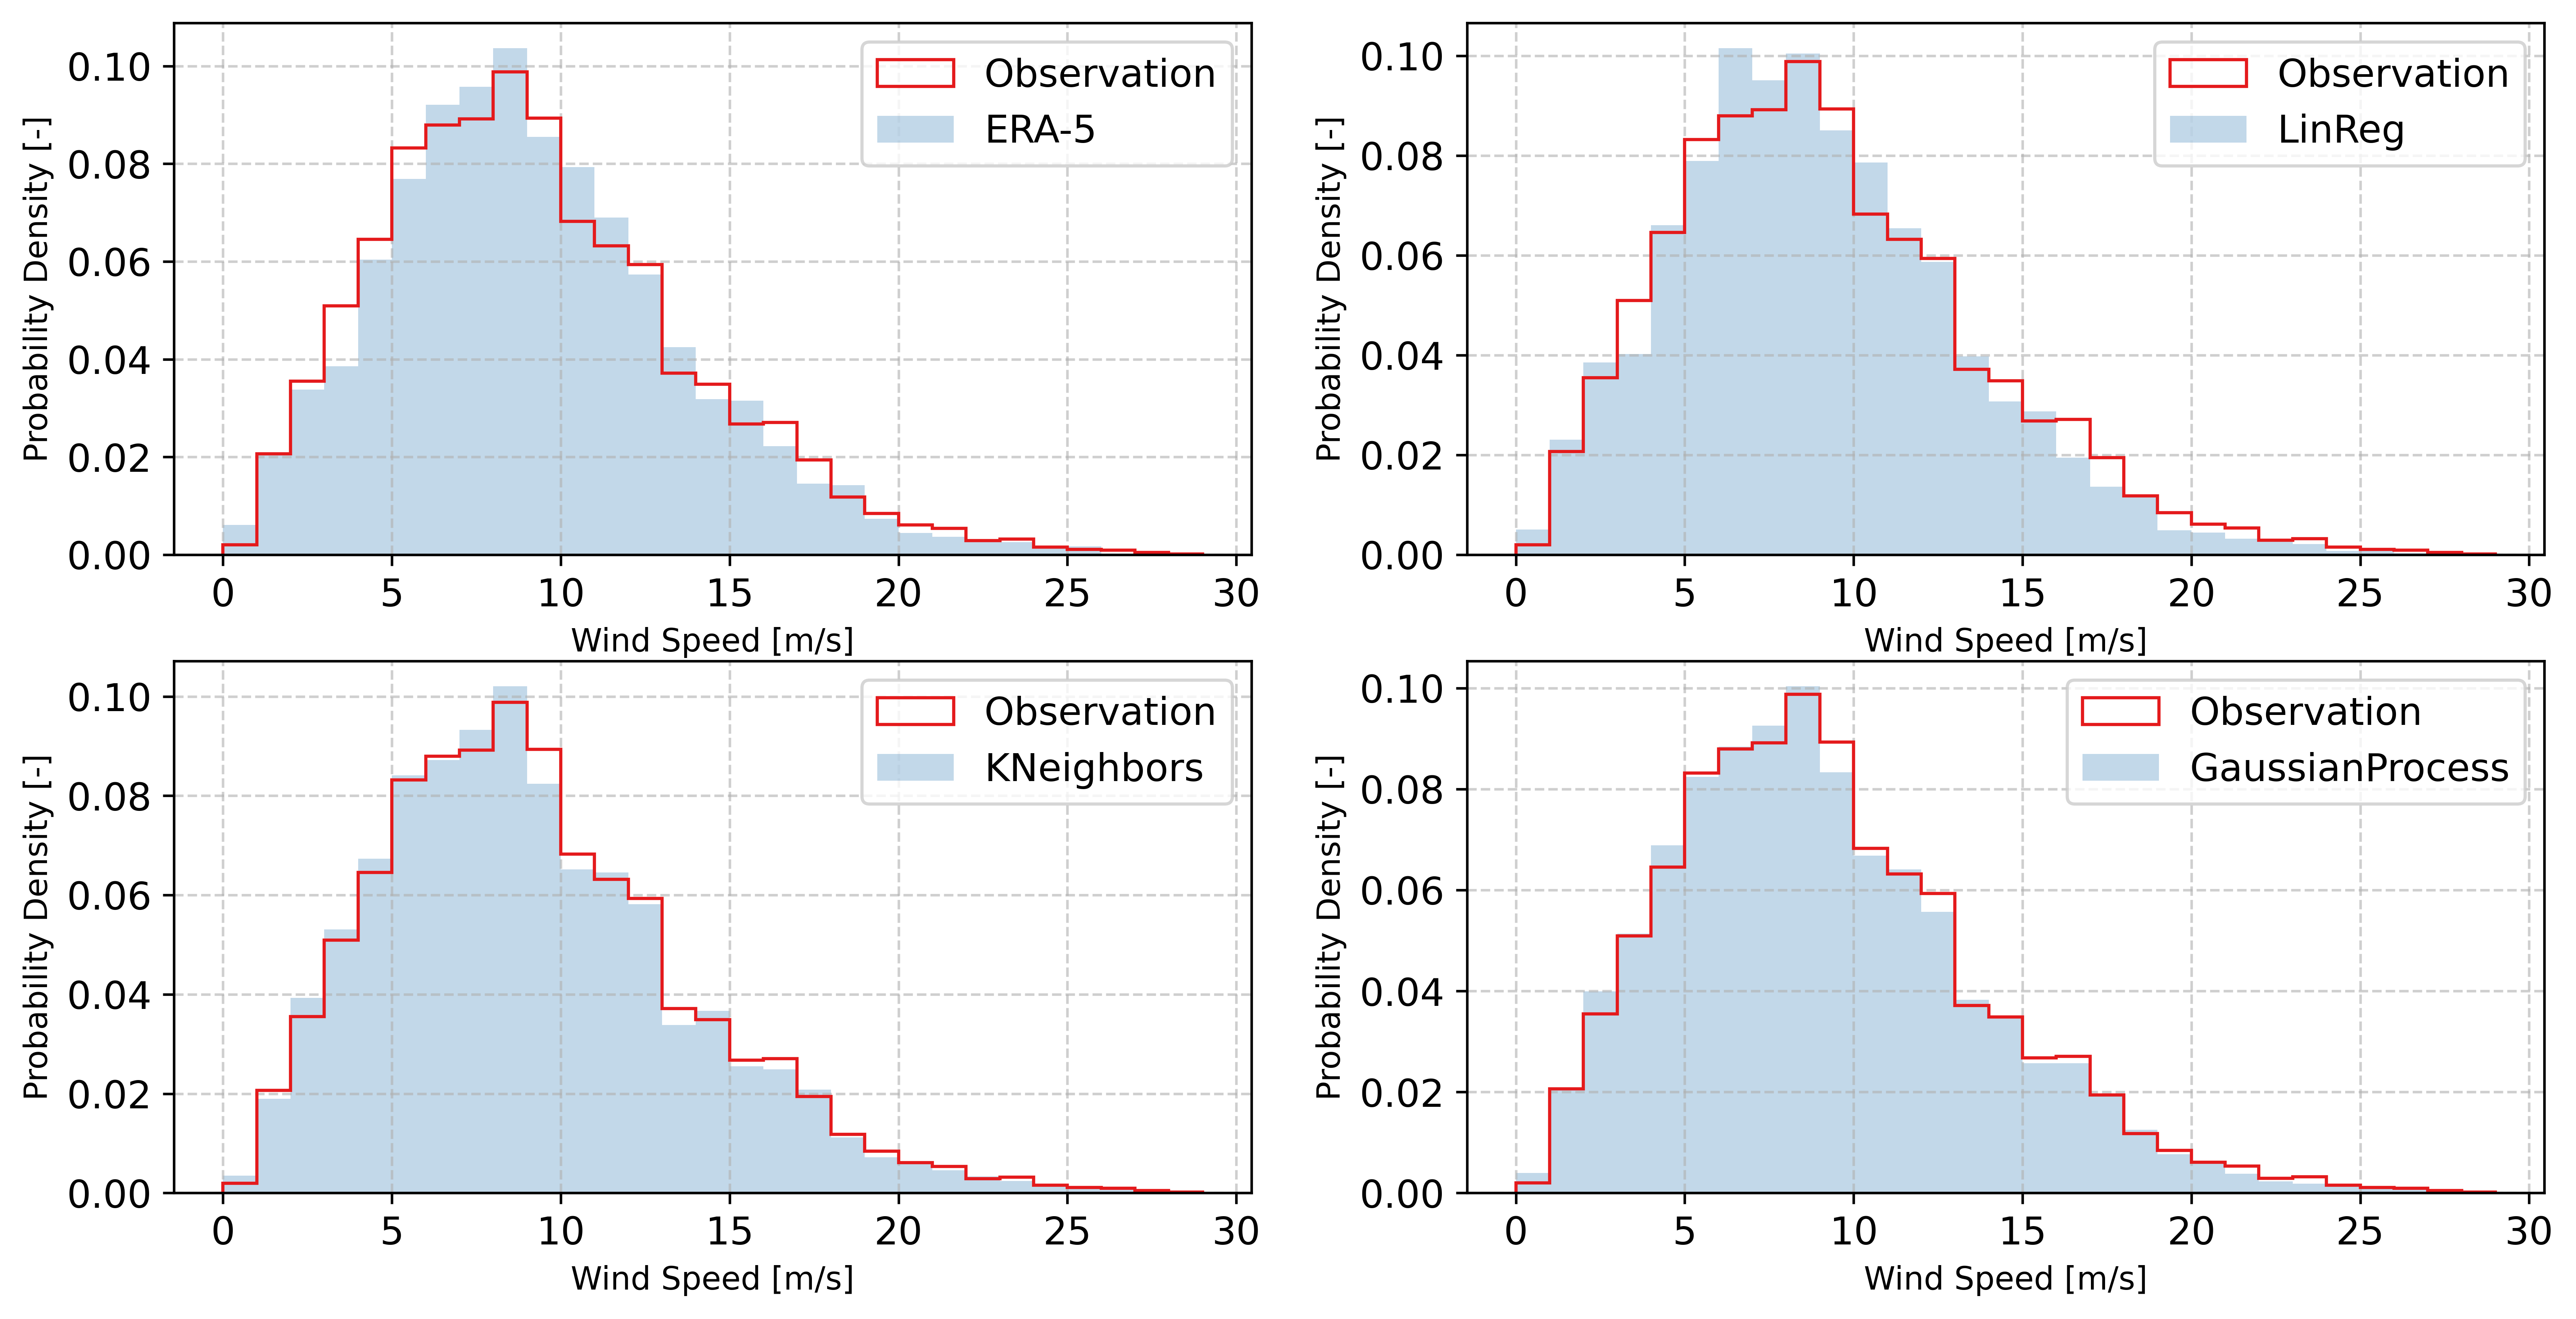

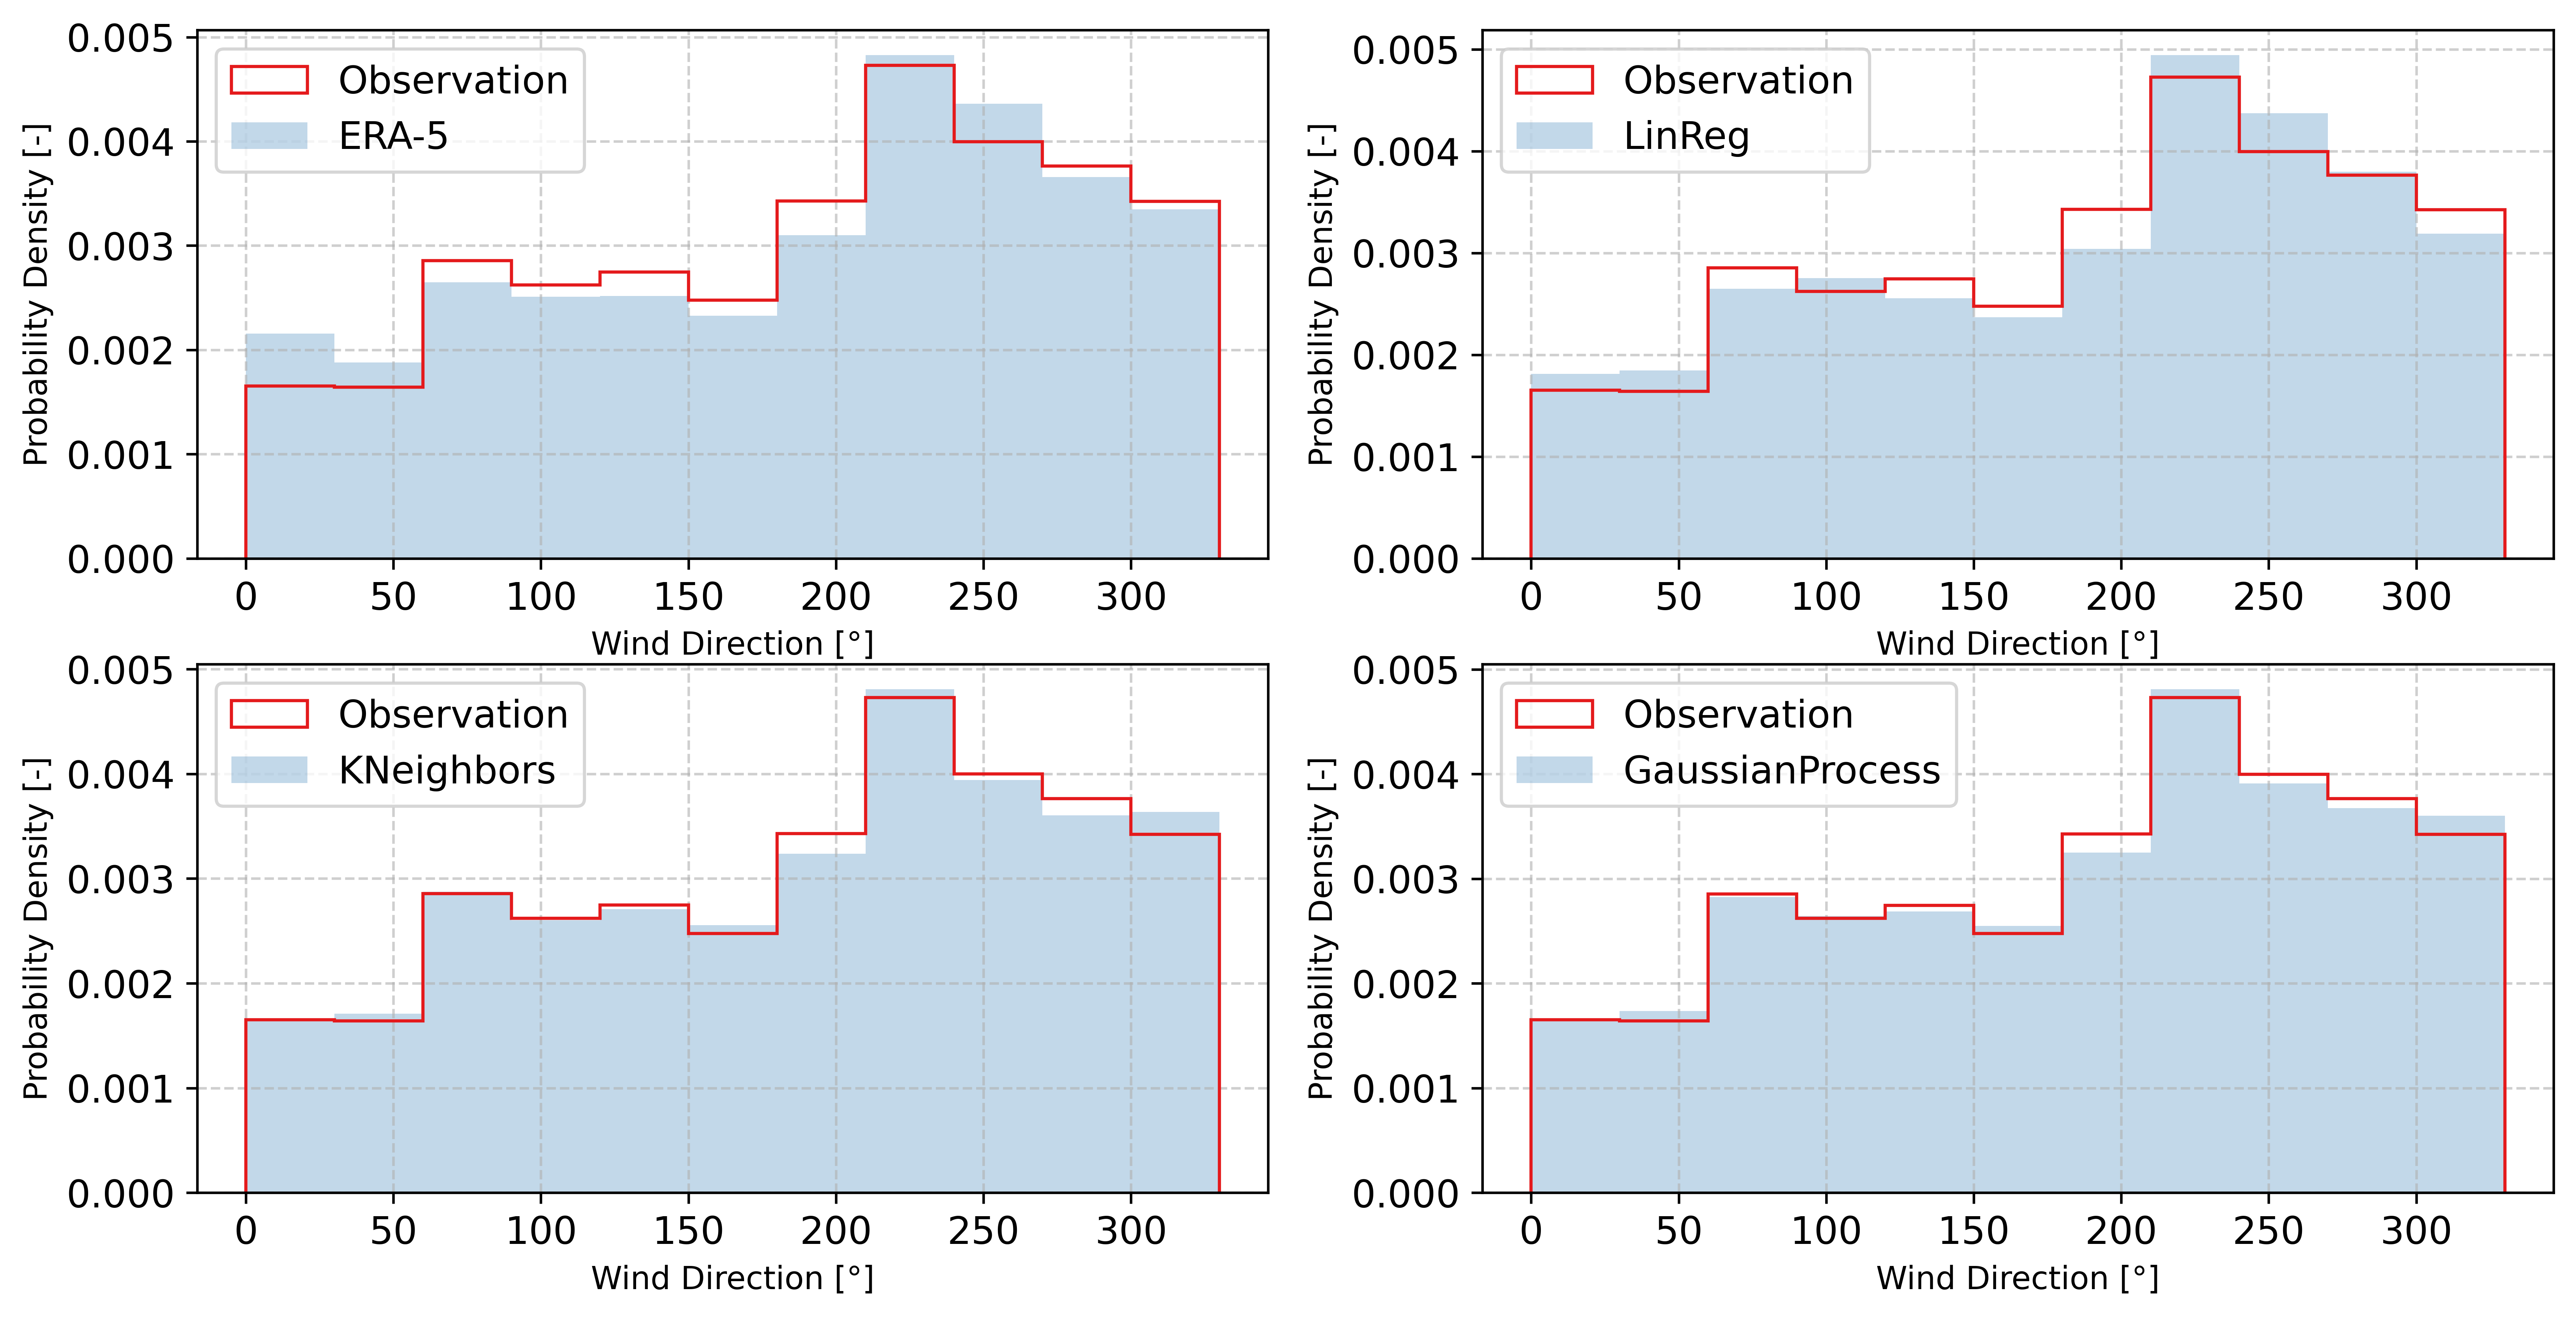

In [3]:
# Unpickle data
meas_idx = np.loadtxt('meas_idx.txt')
wind_data = pd.read_pickle('wind_data')
df_predictions = pd.read_pickle('WS_WD_predictions')

WS_predictions = [df_predictions.iloc[:,i] for i in range(3)]
WD_predictions = [df_predictions.iloc[:,i + 3] for i in range(3)]

nbins = np.arange(0, 30, 1)

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

[axs.hist(wind_data['WS-99.2'].iloc[meas_idx], nbins, label='Observation', histtype='step', density=True) for axs in ax]
ax[0].hist(wind_data['WS100'].iloc[meas_idx], nbins, label='ERA-5', alpha=0.3, density=True)

[ax[i + 1].hist(WS[meas_idx], nbins, label=lbl, alpha=0.3, density=True) for (i, WS, lbl) in zip(range(len(WS_predictions)), WS_predictions, classifier_names)]

for axs in ax:
    axs.legend(fontsize= 12)
    axs.grid(True, linestyle="--", alpha=0.6)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('Wind Speed [m/s]')
    axs.set_ylabel('Probability Density [-]')
plt.show()

nbins = np.arange(0, 360, 30)

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

[axs.hist(wind_data['WD-99.2'].iloc[meas_idx], nbins, label='Observation', histtype='step', density=True) for axs in ax]
ax[0].hist(wind_data['WD100'].iloc[meas_idx], nbins, label='ERA-5', alpha=0.3, density=True)

[ax[i + 1].hist(WD[meas_idx], nbins, label=lbl, alpha=0.3, density=True) for (i, WD, lbl) in zip(range(len(WD_predictions)), WD_predictions, classifier_names)]

for axs in ax:
    axs.legend(fontsize= 12)
    axs.grid(True, linestyle="--", alpha=0.6)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('Wind Direction [°]')
    axs.set_ylabel('Probability Density [-]')
    
plt.show()

## Measurement Matrix

| Layout  | area_of_interest | aoi + existing turbines |
|---------|------------------|-------------------------|
| Control | ambient = True   | ambient = True          |
| Results | ambient = False  | ambient = False         |

### Load Wind Park Layouts

In [4]:
# Unpickle wind_data
wind_data = pd.read_pickle('wind_data')

# Define the coordinate path
coords_path = 'turbine-info/coordinates'
# Iterate through all directories in coords_path and store each file path for each directory in a list, which is stored in a list
# e.g. total_layout[0] contains all file paths of all .csv files in the first directory in coords_path, which is 'area_of_interest'
# read all layouts in a list of dataframes such that layout_dfs[0] is the combined layout of all paths in 'area_of_interest' and so on
layout_dfs = [pd.concat([pd.read_csv(file.path) for file in os.scandir(_dir) if file.path.endswith(".csv")]).sort_values(by='y', ascending=False).reset_index(inplace=False)
              for _dir in 
              [_dir.path for _dir in os.scandir(coords_path) if _dir.is_dir()]]

dist_lim = 50000    # distance limit of external turbines from the center of the area of interest

AoI_center = [np.average(layout_dfs[0]['x']), np.average(layout_dfs[0]['y'])]   # Center of the area of interest

ex_layouts = layout_dfs[1:].copy()  # copy all external layouts

for l in ex_layouts:
    for idx, coordinate in enumerate(l[['x', 'y']].values):
        if np.sqrt((AoI_center[0] - coordinate[0])**2 + (AoI_center[1] - coordinate[1])**2) >= dist_lim:
            
            # drop each turbine from the external layouts, that is too far from the center of the AoI
            l.drop(idx, inplace=True, axis=0)

# Setup of the Algorithms

In [5]:
start_date = "2006-01-01"
end_date = "2006-12-31 23:59"
date_chunks = [pd.date_range(start_date, end_date, freq=pd.DateOffset(months=1)), 
               pd.date_range(start_date, end_date, freq='ME') + pd.DateOffset(hours=23, minutes=59)]

wake_models = [["Bastankhah2014_quadratic_ka02"], ["Bastankhah2014_linear_k004", "IECTI2019k_linear_k004"], ["TurbOPark_quadratic_loc_k004"]] # , "CrespoHernandez_max_k004"

AoI_algo = [[fct.setup_algo(
                            wind_data=wind_data[['WS100_corr', 'WD100_corr', 'TI']].loc[start:end],
                            windfarm_name="N-10.1/N-10.2",
                            wake_models=wake_model,
                            layout_data=layout_dfs[0]) for start, end in zip(date_chunks[0], date_chunks[1])] for wake_model in wake_models
            ]


AoI_ex_algo = [fct.setup_algo(
                              wind_data=wind_data[['WS100_corr', 'WD100_corr', 'TI']].loc[start:end],
                              windfarm_name="N-10.1/N-10.2 + External Farms",
                              wake_models=["Bastankhah2014_quadratic_ka02"],
                              layout_data=pd.concat([layout_dfs[0], pd.concat(ex_layouts)])
                              ) for start, end in zip(date_chunks[0], date_chunks[1])
              ]

Turbine 0, T0: xy=(299005.80, 6070368.13), DTU10MW
Turbine 1, T1: xy=(298349.95, 6069364.01), DTU10MW
Turbine 2, T2: xy=(299546.60, 6069298.19), DTU10MW
Turbine 3, T3: xy=(300744.40, 6069255.93), DTU10MW
Turbine 4, T4: xy=(302075.57, 6068404.37), DTU10MW
Turbine 5, T5: xy=(298529.18, 6068179.05), DTU10MW
Turbine 6, T6: xy=(299725.82, 6068113.23), DTU10MW
Turbine 7, T7: xy=(300923.62, 6068070.97), DTU10MW
Turbine 8, T8: xy=(297371.96, 6067866.68), DTU10MW
Turbine 9, T9: xy=(303085.54, 6067758.28), DTU10MW
Turbine 10, T10: xy=(301715.50, 6067171.26), DTU10MW
Turbine 11, T11: xy=(304095.51, 6067112.19), DTU10MW
Turbine 12, T12: xy=(299341.24, 6066978.00), DTU10MW
Turbine 13, T13: xy=(298142.83, 6066947.93), DTU10MW
Turbine 14, T14: xy=(300539.04, 6066935.73), DTU10MW
Turbine 15, T15: xy=(302771.25, 6066601.55), DTU10MW
Turbine 16, T16: xy=(305105.47, 6066466.11), DTU10MW
Turbine 17, T17: xy=(301478.71, 6065995.11), DTU10MW
Turbine 18, T18: xy=(303781.22, 6065955.46), DTU10MW
Turbine 19, T

## Do not run the next two cells, if you ran them once before !!!

In [6]:
# Simulate the wind farm without external wind turbines
AoI_res_list = [[algo.calc_farm() for algo in wake_model] for wake_model in AoI_algo]
# Store the results of the simulation to not have to run this simulation each time
[[res.to_netcdf('./AoI_res/AoI_res_' + str(idx) + '/' + str(i) + '.nc') for i, res in zip(range(len(AoI_res)), AoI_res)] for idx, AoI_res in enumerate(AoI_res_list)]

Selecting 'DefaultEngine(n_procs=16, chunk_size_states=None, chunk_size_points=None)'
DefaultEngine: Selecting engine 'process'
ProcessEngine: Calculating 744 states for 166 turbines
ProcessEngine: Computing 16 chunks using 16 processes


100%|██████████| 16/16 [00:05<00:00,  2.74it/s]


DefaultEngine: Selecting engine 'process'
ProcessEngine: Calculating 672 states for 166 turbines
ProcessEngine: Computing 16 chunks using 16 processes


100%|██████████| 16/16 [00:05<00:00,  2.74it/s]


DefaultEngine: Selecting engine 'process'
ProcessEngine: Calculating 744 states for 166 turbines
ProcessEngine: Computing 16 chunks using 16 processes


...

DefaultEngine: Selecting engine 'process'
ProcessEngine: Calculating 720 states for 166 turbines
ProcessEngine: Computing 16 chunks using 16 processes


100%|██████████| 16/16 [00:05<00:00,  2.68it/s]


DefaultEngine: Selecting engine 'process'
ProcessEngine: Calculating 744 states for 166 turbines
ProcessEngine: Computing 16 chunks using 16 processes


100%|██████████| 16/16 [00:06<00:00,  2.63it/s]


[[None, None, None, None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None, None, None, None]]

In [ ]:
# Simulate the wind farm with external wind turbines
AoI_ex_res = [algo.calc_farm() for algo in AoI_ex_algo]
# Store the results of the simulation to not have to run this simulation each time
[res.to_netcdf('./AoI_ex_res/AoI_ex_res' + str(i) + '.nc') for i, res in zip(range(len(AoI_ex_res)), AoI_ex_res)]

## The output from above gets read in here !!!

In [8]:
# Load the stored .nc files
AoI_res = [[xr.open_dataset(file, engine="netcdf4") for file in os.scandir(_dir) if file.path.endswith(".nc")] for _dir in 
              [_dir.path for _dir in os.scandir('./AoI_res') if _dir.is_dir()]]
AoI_ex_res = [xr.open_dataset(file, engine="netcdf4") for file in os.scandir('./AoI_ex_res') if file.path.endswith(".nc")]


AoI_WT_stats, AoI_summary = [[fct.extract_results(res, algo)[0] for res, algo in zip(AoI_res, AoI_algo)], 
                             [fct.extract_results(res, algo)[1] for res, algo in zip(AoI_res, AoI_algo)]]
AoI_ex_WT_stats, AoI_ex_summary = fct.extract_results(AoI_ex_res, AoI_ex_algo)

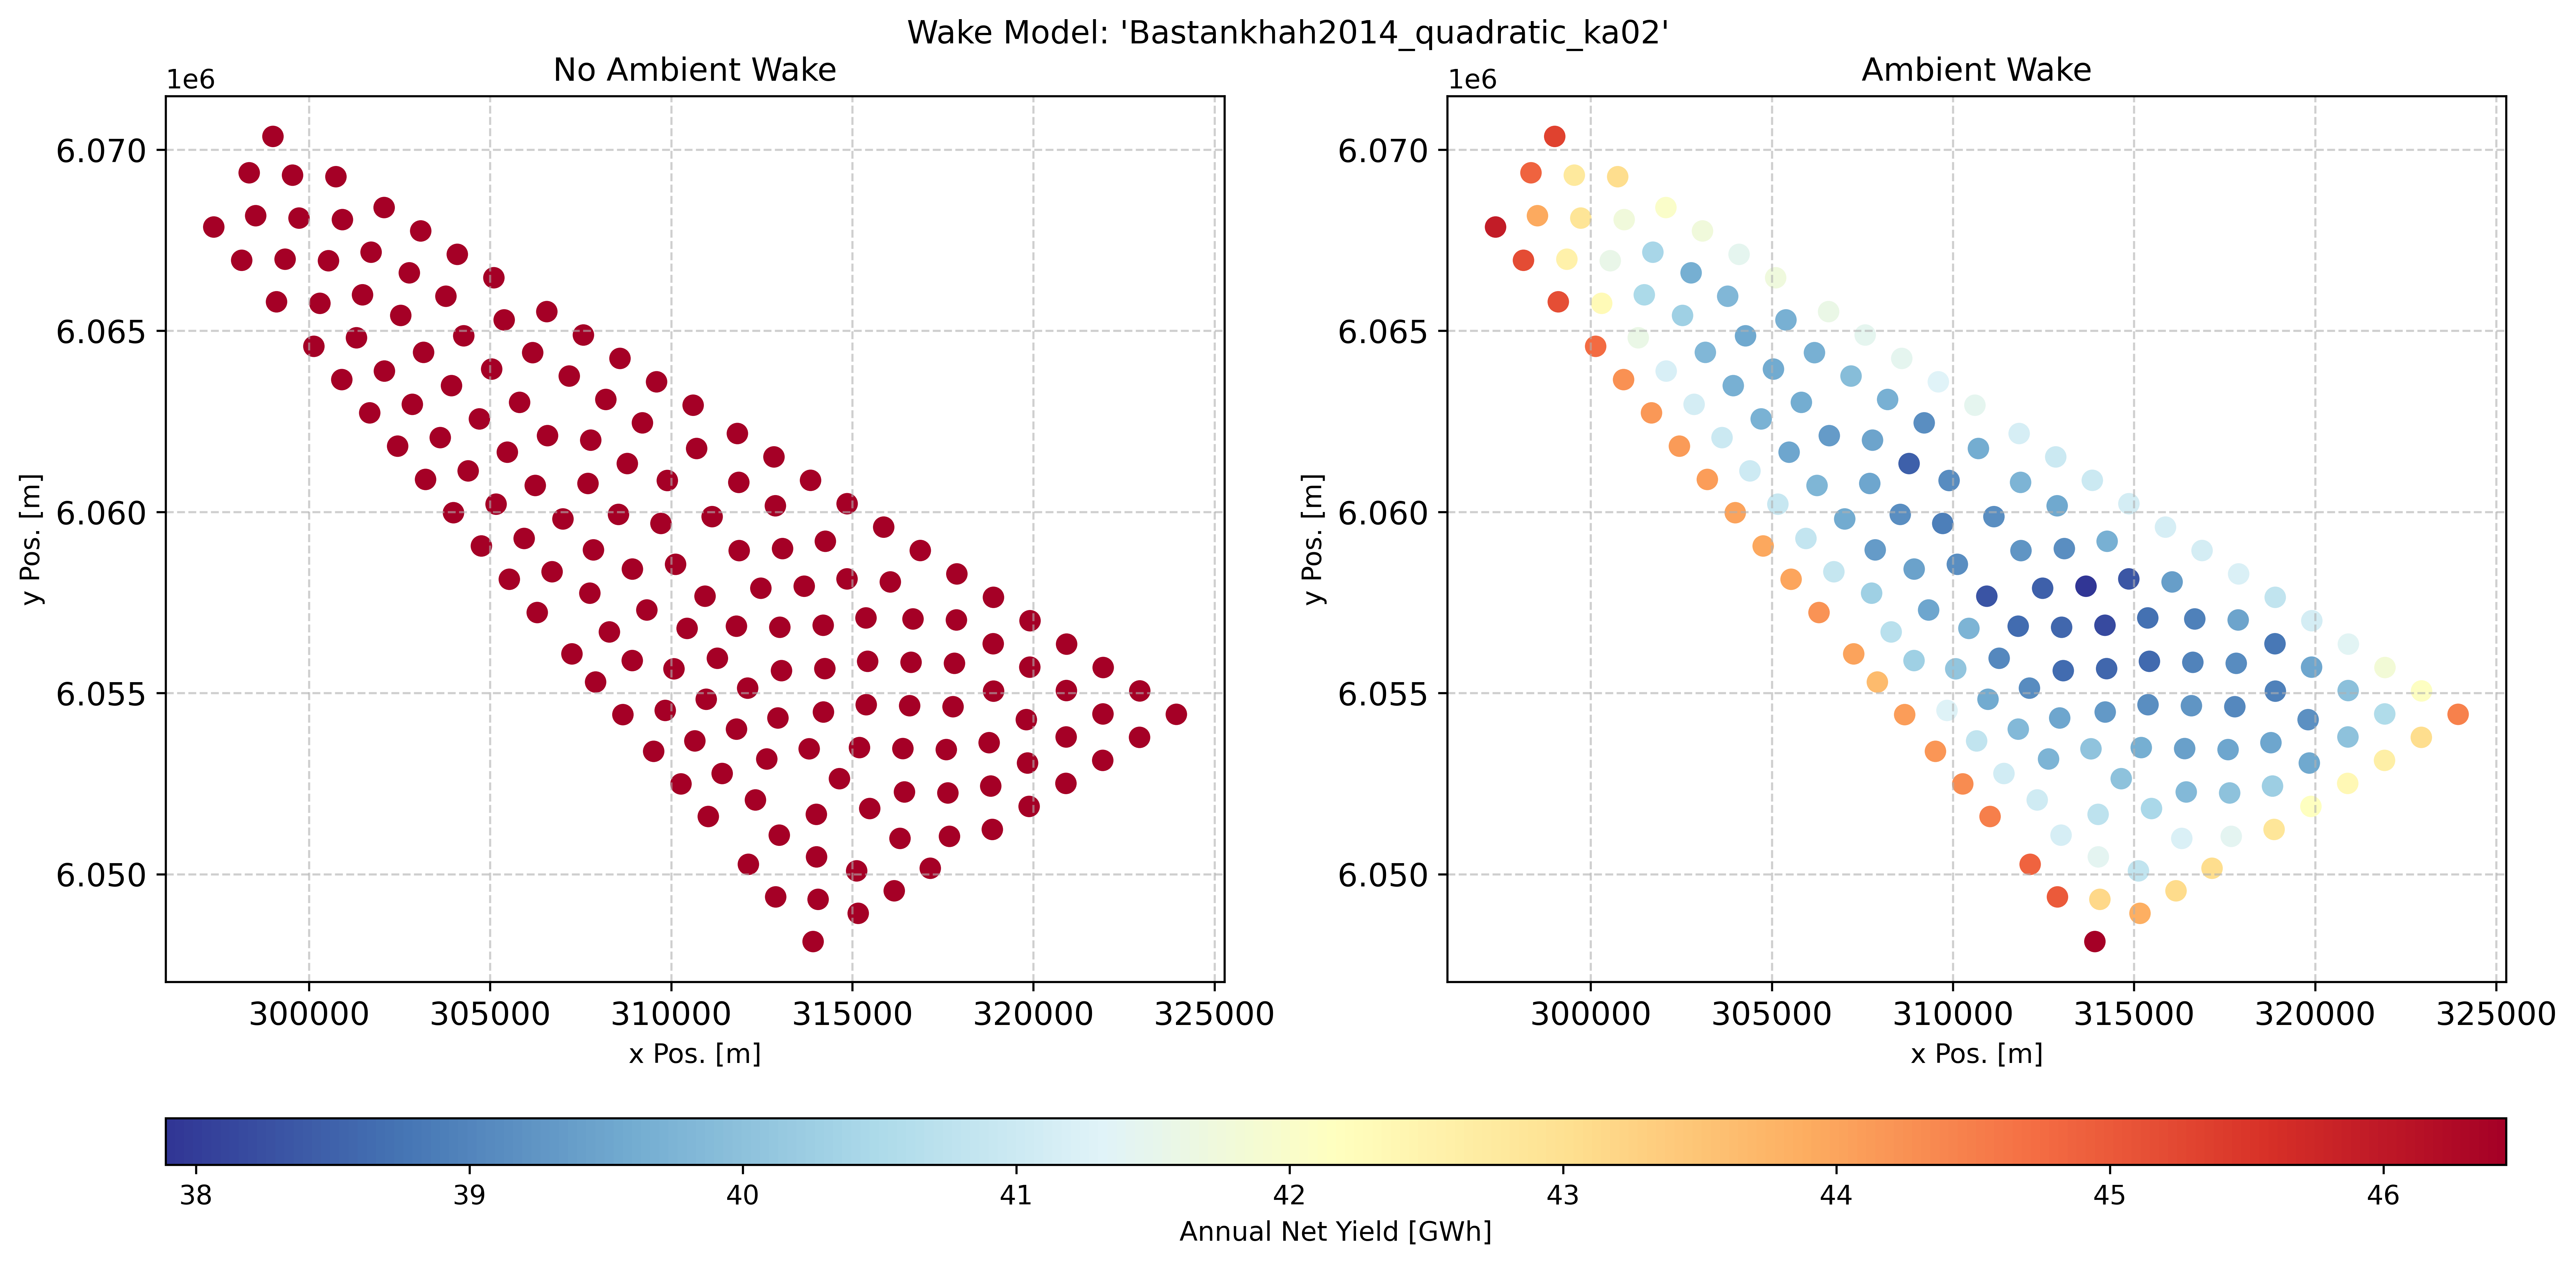

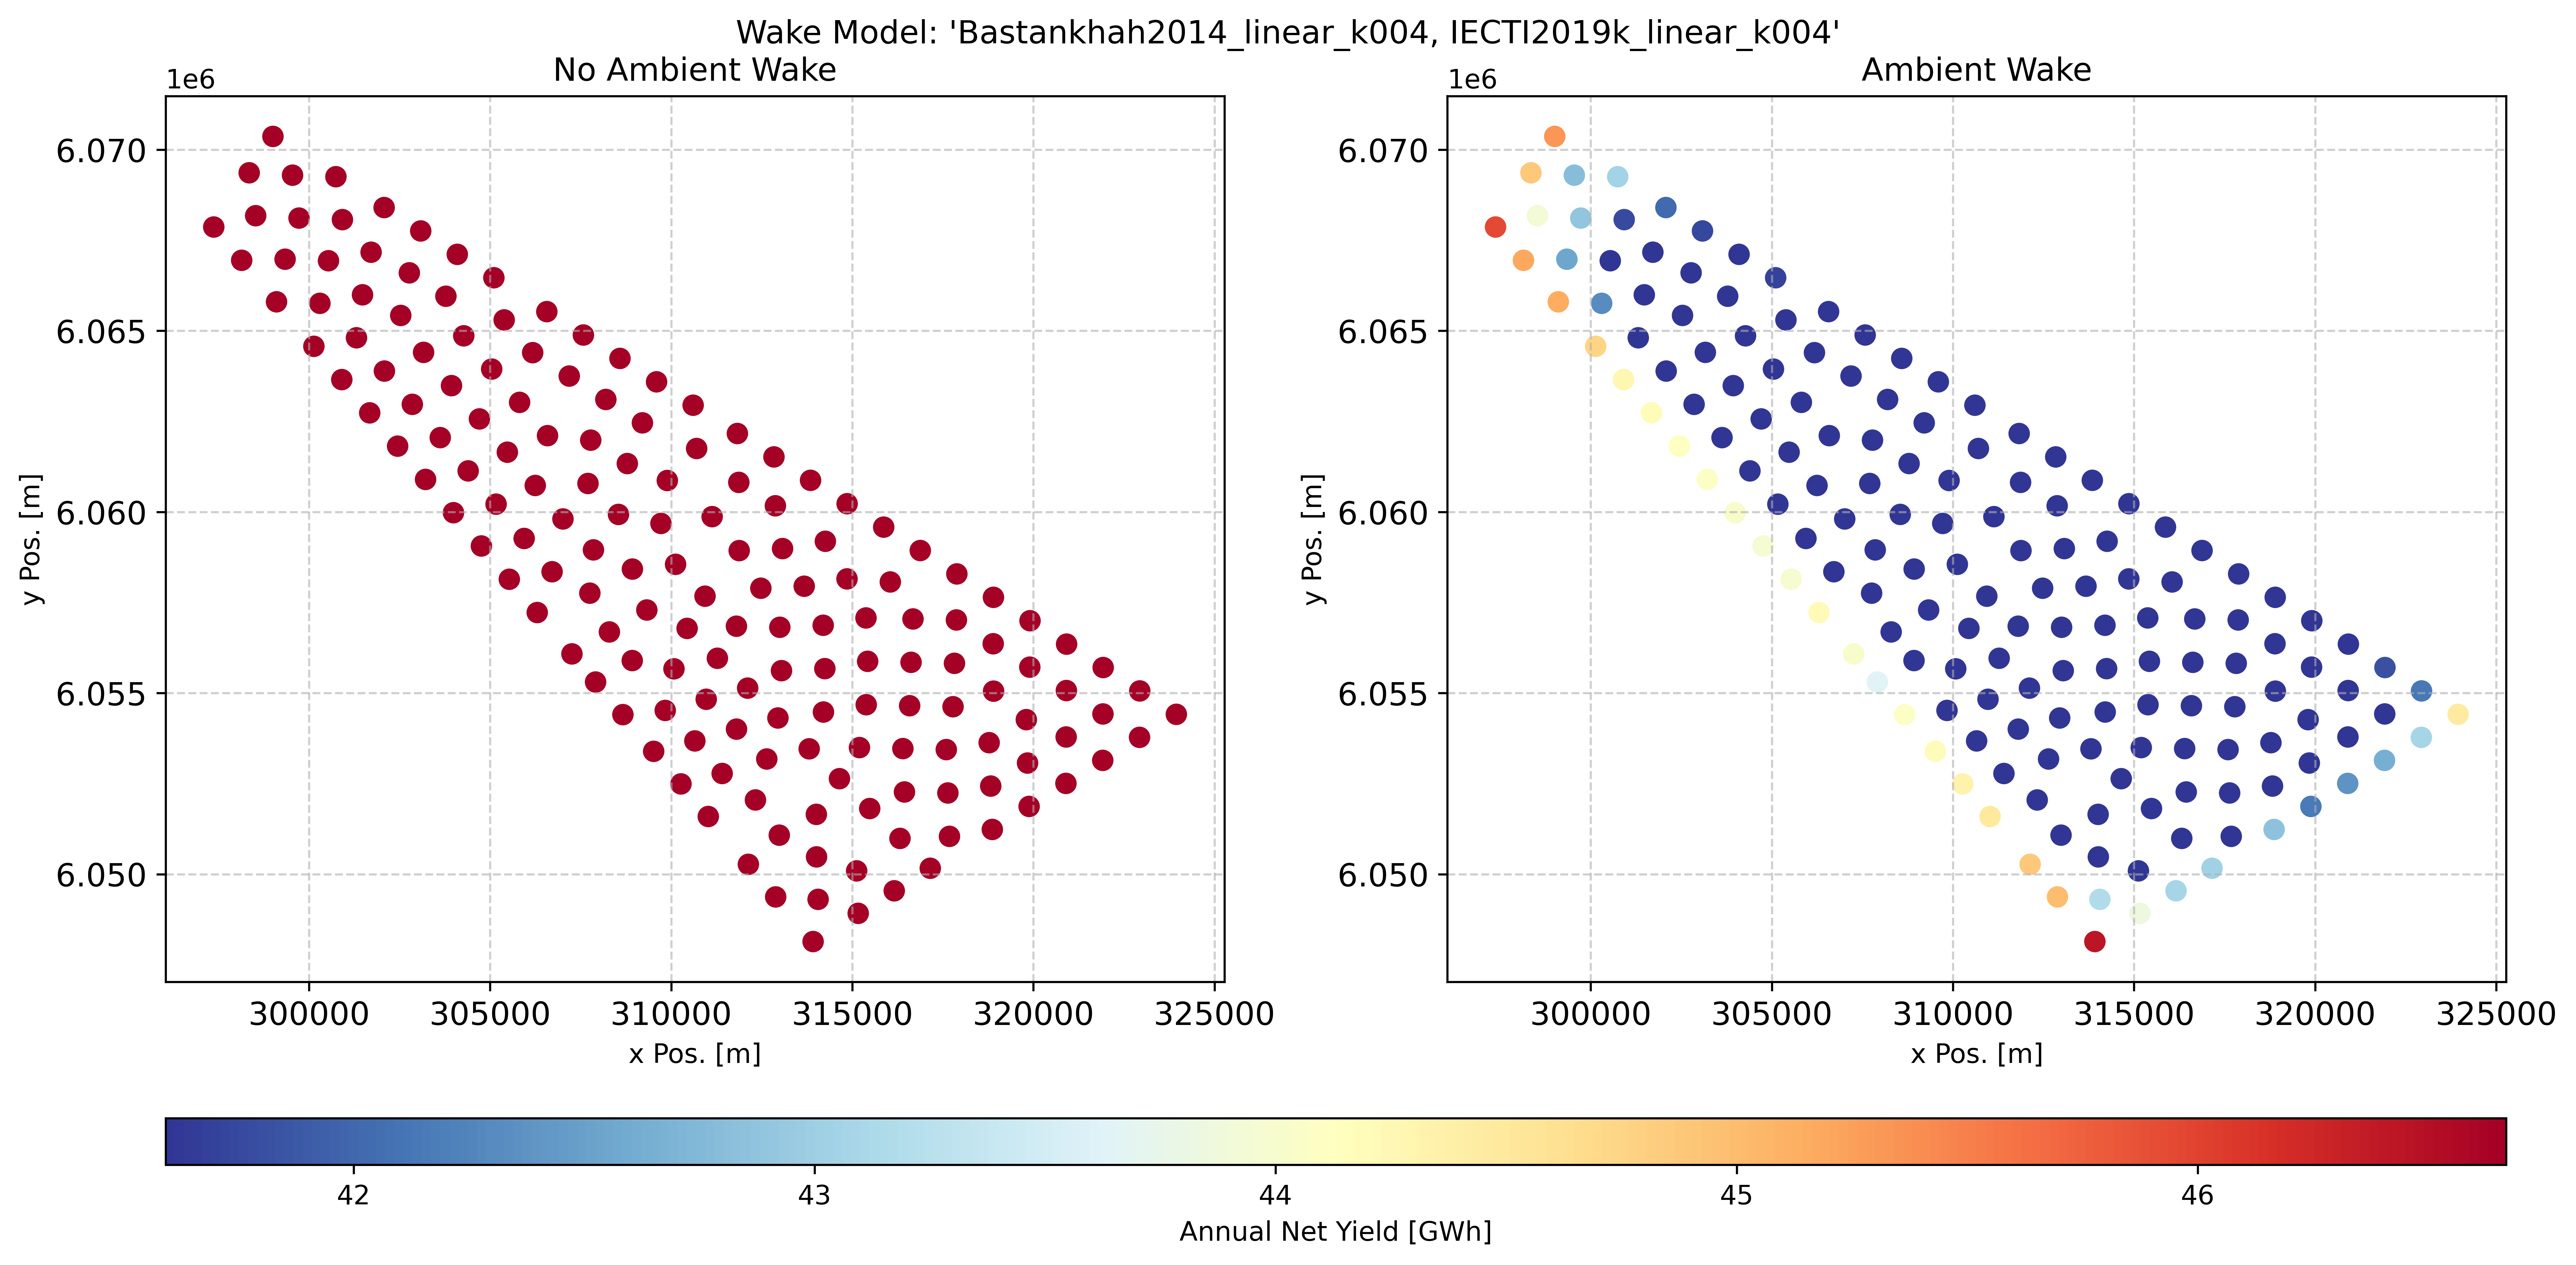

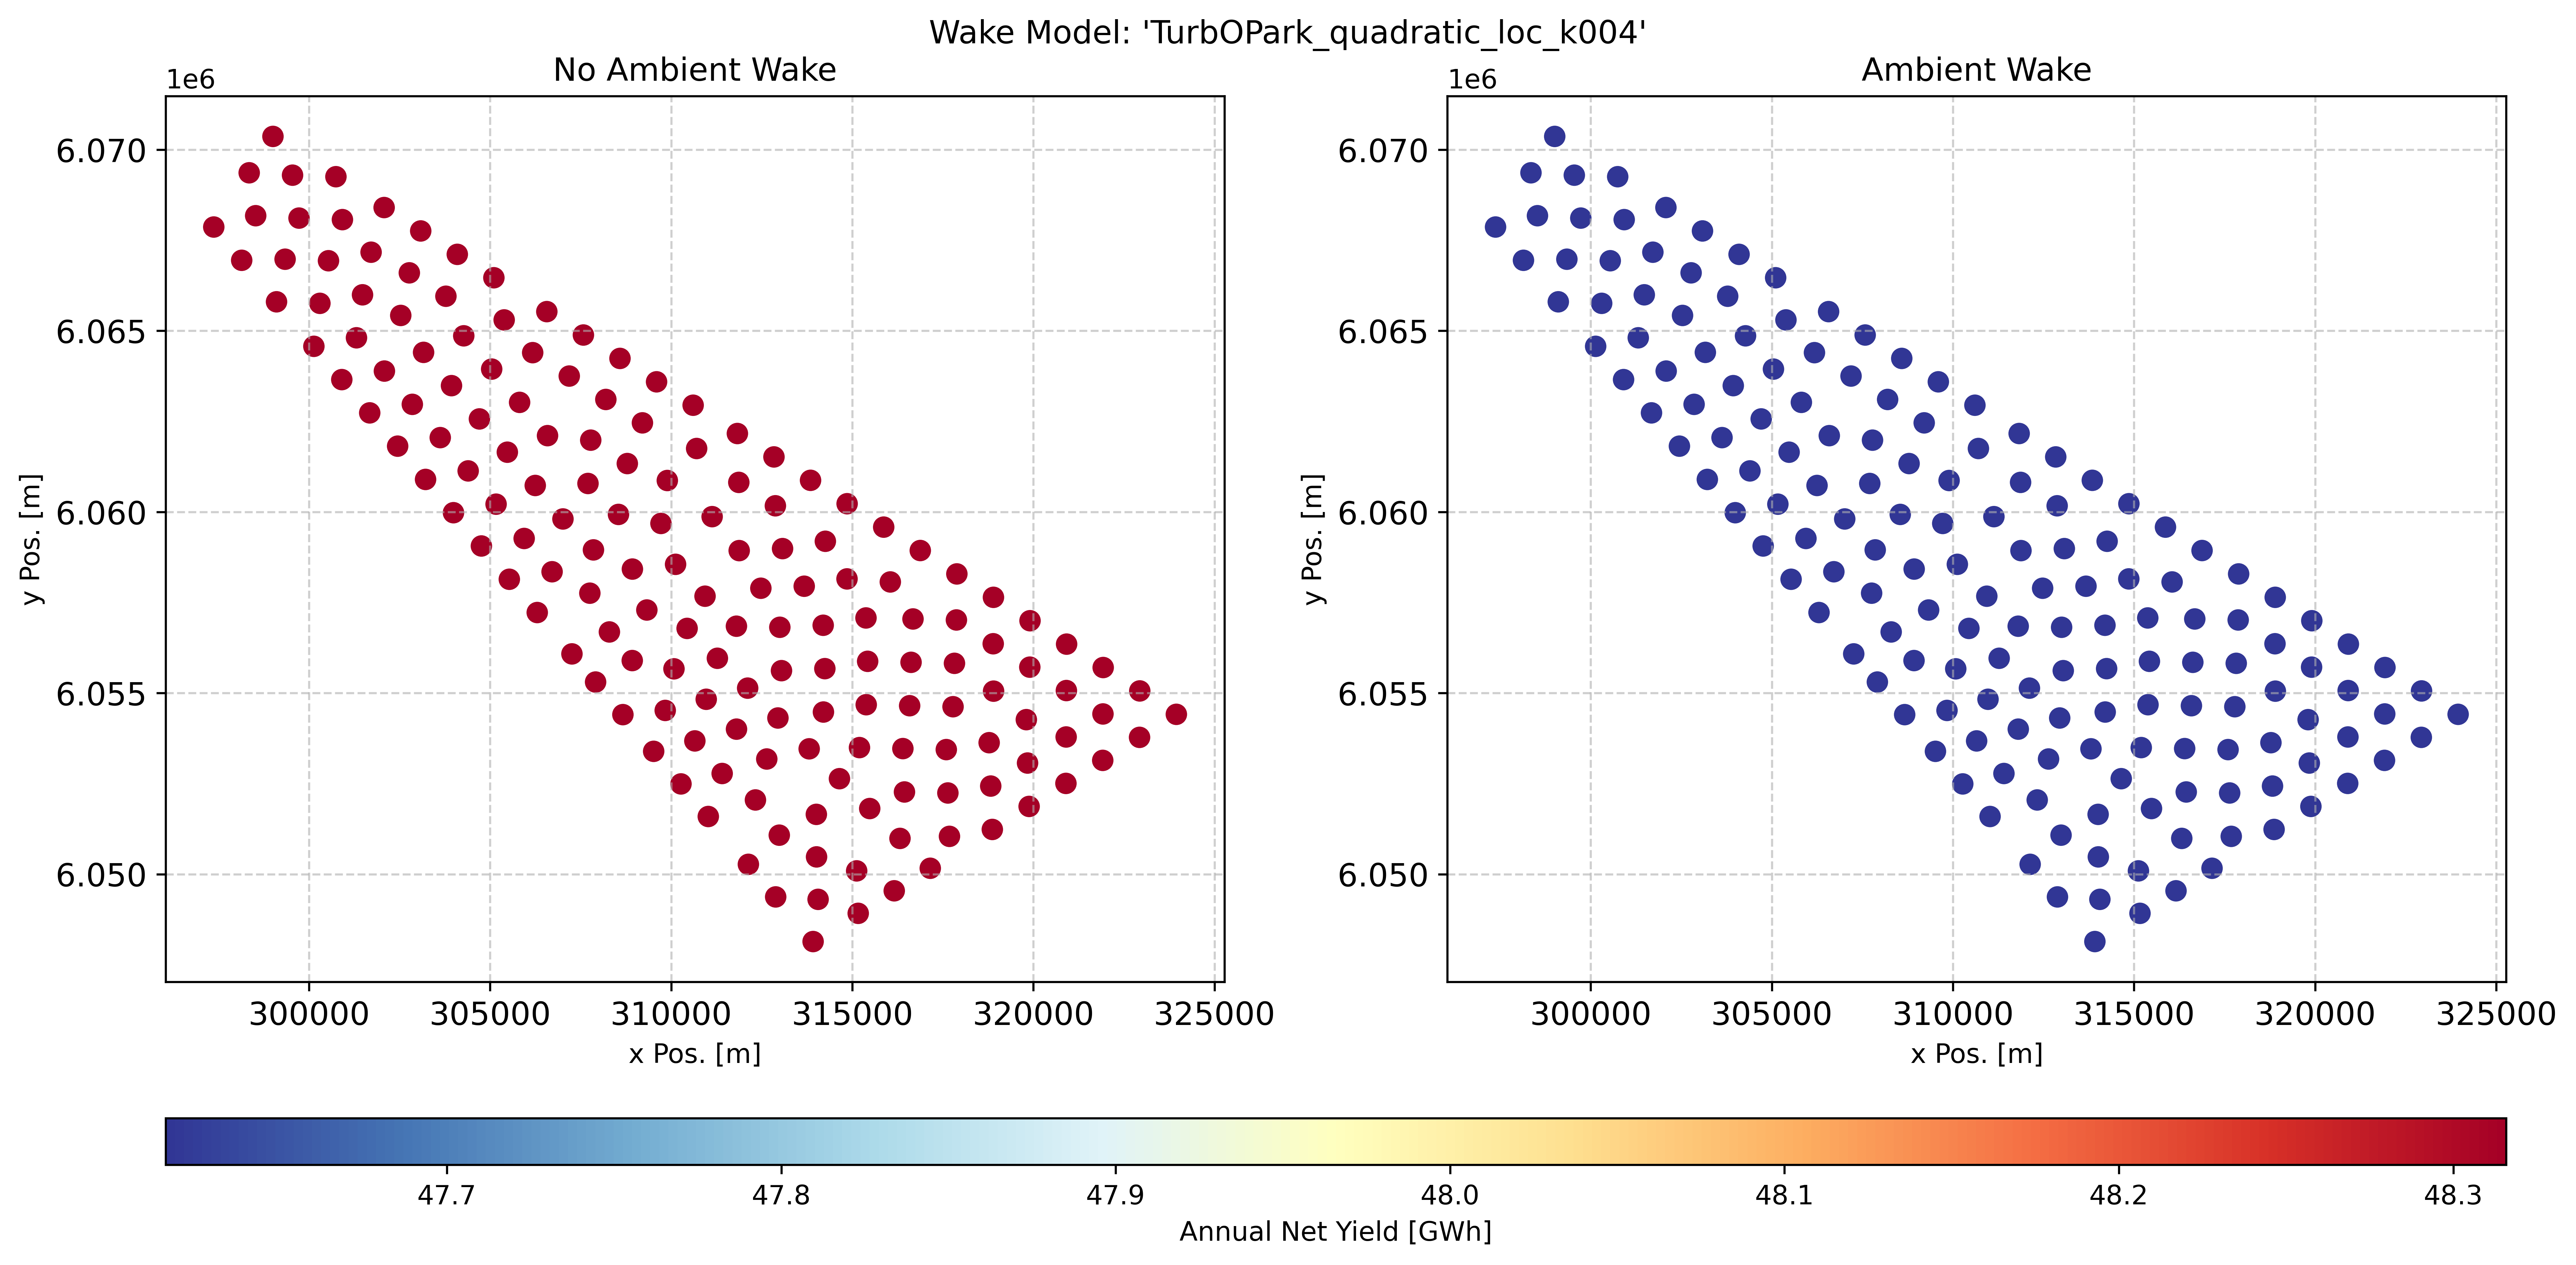

In [10]:

for WT_stats, wake_model in zip(AoI_WT_stats, wake_models):
    
    fig, ax = plt.subplots(1, 2, layout='compressed')
    ax = ax.flatten()
    
    cbar_min = min(WT_stats['Net Yield [GWh]'].values.min(), WT_stats['Net Ambient Yield [GWh]'].values.min())
    cbar_max = WT_stats['Net Yield [GWh]'].values.max()
    norm = Normalize(vmin=cbar_min, vmax=cbar_max)
    
    ax[0].scatter(layout_dfs[0]['x'], layout_dfs[0]['y'], c=AoI_WT_stats[0]['Net Ambient Yield [GWh]'].values, norm=norm, cmap="RdYlBu_r", s=50)
    ax[0].set_title('No Ambient Wake')
    
    sc = ax[1].scatter(layout_dfs[0]['x'], layout_dfs[0]['y'], c=AoI_WT_stats[0]['Net Yield [GWh]'].values, norm=norm, cmap="RdYlBu_r", s=50)
    ax[1].set_title('Ambient Wake')
    
    for axs in ax:
        axs.grid(True, linestyle="--", alpha=0.6)
        axs.xaxis.set_tick_params(labelsize=12)
        axs.yaxis.set_tick_params(labelsize=12)
        axs.set_xlabel('x Pos. [m]')
        axs.set_ylabel('y Pos. [m]')
        axs.set_aspect('equal', 'box')
        
    fig.suptitle("Wake Model: '" + ', '.join(wake_model) + "'")
    plt.colorbar(sc, label="Annual Net Yield [GWh]", ax=ax.ravel().tolist(), location='bottom', aspect=50)
    plt.show()

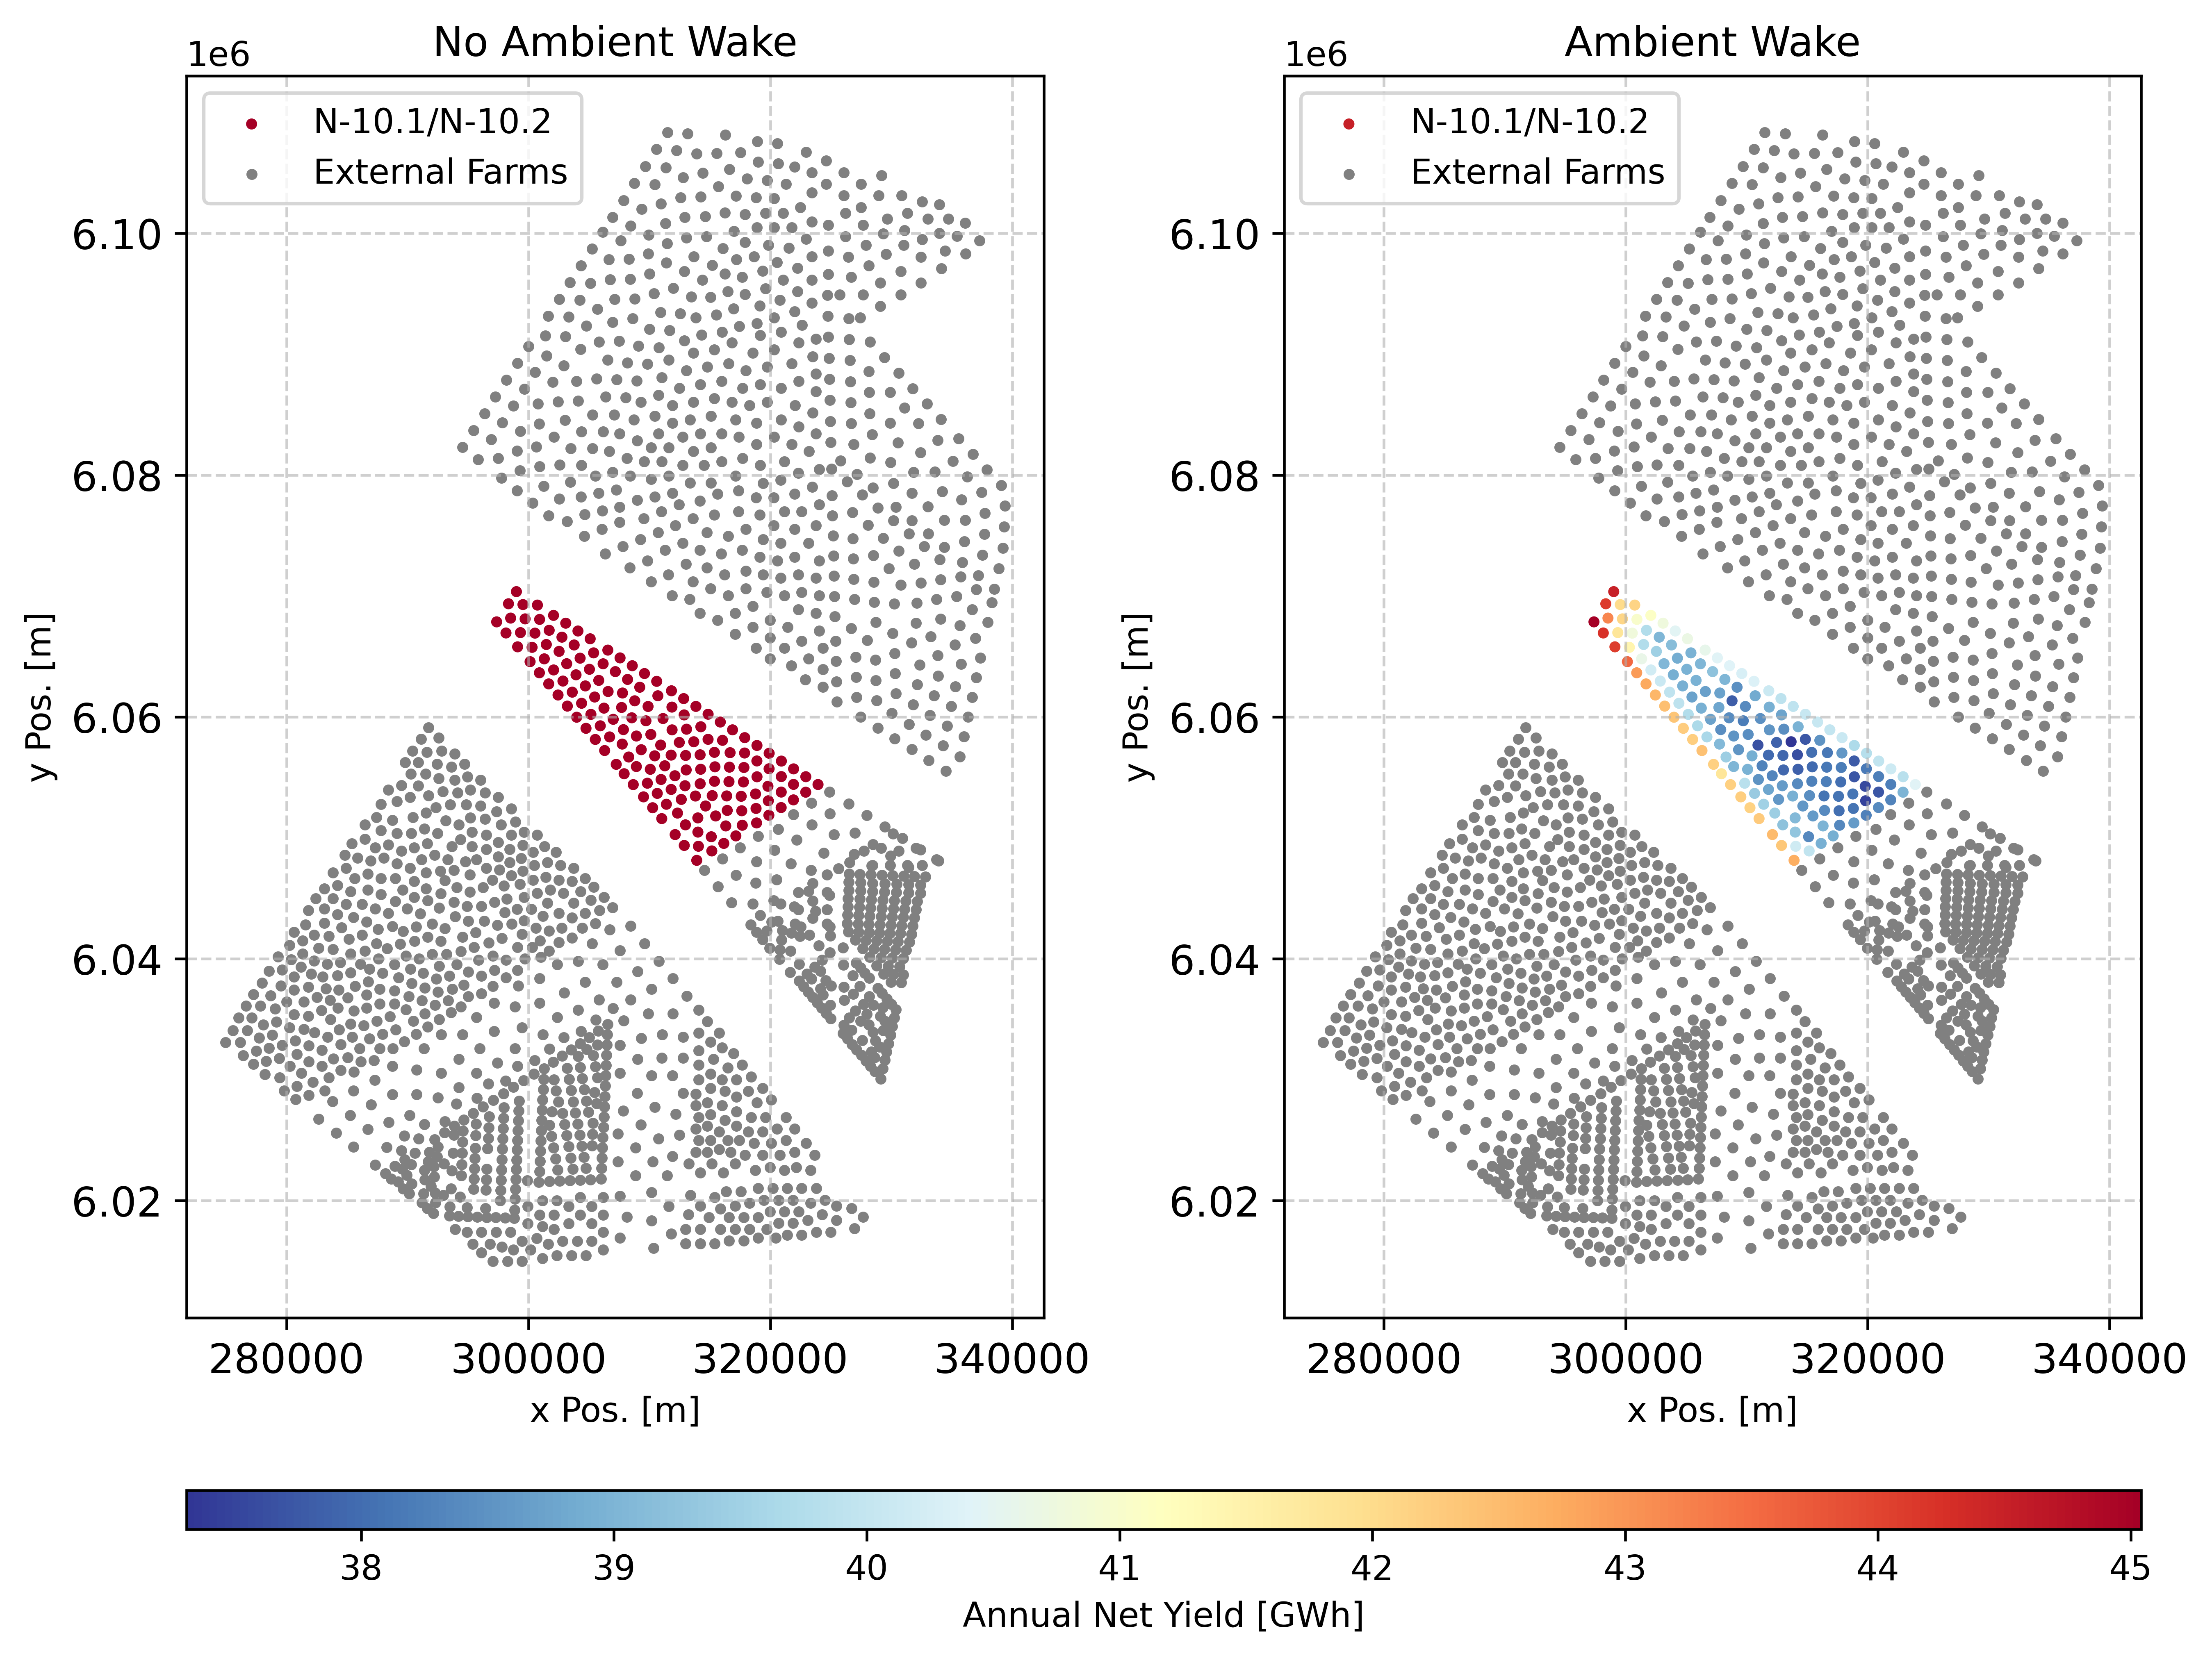

In [29]:
fig, ax = plt.subplots(1, 2, layout='compressed')
ax = ax.flatten()

cbar_min = AoI_ex_WT_stats['Net Yield [GWh]'].values[:166].min()
cbar_max = AoI_ex_WT_stats['Net Yield [GWh]'].values[:166].max()
norm = Normalize(vmin=cbar_min, vmax=cbar_max)

ax[0].scatter(layout_dfs[0]['x'],
              layout_dfs[0]['y'], 
              c=AoI_ex_WT_stats['Net Ambient Yield [GWh]'].values[:166], 
              norm=norm, 
              cmap="RdYlBu_r", 
              s=5,
              label='N-10.1/N-10.2')
ax[0].scatter(pd.concat(ex_layouts)['x'], pd.concat(ex_layouts)['y'], 
              c='grey', 
              s=5,
              label='External Farms')
ax[0].set_title('No Ambient Wake')

sc = ax[1].scatter(layout_dfs[0]['x'], 
                   layout_dfs[0]['y'], 
                   c=AoI_ex_WT_stats['Net Yield [GWh]'].values[:166], 
                   norm=norm, 
                   cmap="RdYlBu_r", 
                   s=5,
                   label='N-10.1/N-10.2')
ax[1].scatter(pd.concat(ex_layouts)['x'], pd.concat(ex_layouts)['y'], 
              c='grey', 
              s=5,
              label='External Farms')
ax[1].set_title('Ambient Wake')

for axs in ax:
    axs.grid(True, linestyle="--", alpha=0.6)
    axs.xaxis.set_tick_params(labelsize=12)
    axs.yaxis.set_tick_params(labelsize=12)
    axs.set_xlabel('x Pos. [m]')
    axs.set_ylabel('y Pos. [m]')
    axs.set_aspect('equal', 'box')
    axs.legend()
    
plt.colorbar(sc, label="Annual Net Yield [GWh]", ax=ax.ravel().tolist(), location='bottom', aspect=50)
plt.show()